# 01 — Exploratory Data Analysis

Goal: understand the raw creditcard dataset before touching a model.
Outputs feed directly into feature engineering decisions in notebook 03.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 284,807 rows × 31 columns


## 1. Basic structure

In [4]:
print(df.dtypes)
df.head(3)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing: 0


## 2. Class balance

Legitimate : 284,315
Fraud      : 492
Fraud rate : 0.1727%


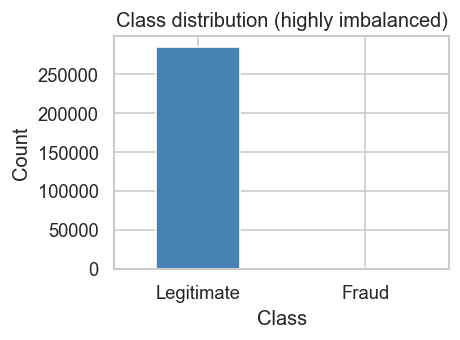

In [7]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean() * 100
print(f"Legitimate : {class_counts[0]:,}")
print(f"Fraud      : {class_counts[1]:,}")
print(f"Fraud rate : {fraud_rate:.4f}%")

fig, ax = plt.subplots(figsize=(4, 3))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax.set_title('Class distribution (highly imbalanced)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/01_class_balance.png')
plt.show()

## 3. Amount distribution

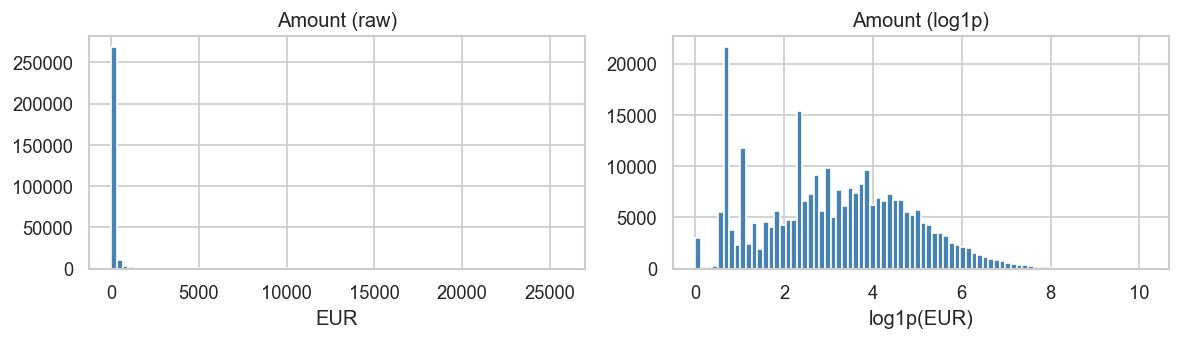

Raw Amount  — mean: 88.35, median: 22.00, max: 25691.16
Fraud mean  : 122.21
Legit mean  : 88.29


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

df['Amount'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Amount (raw)')
axes[0].set_xlabel('EUR')

np.log1p(df['Amount']).hist(bins=80, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Amount (log1p)')
axes[1].set_xlabel('log1p(EUR)')

plt.tight_layout()
plt.savefig('../reports/figures/01_amount_distribution.png')
plt.show()

print(f"Raw Amount  — mean: {df['Amount'].mean():.2f}, median: {df['Amount'].median():.2f}, max: {df['Amount'].max():.2f}")
print(f"Fraud mean  : {df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Legit mean  : {df[df['Class']==0]['Amount'].mean():.2f}")

## 4. Time feature — hour-of-day fraud rate

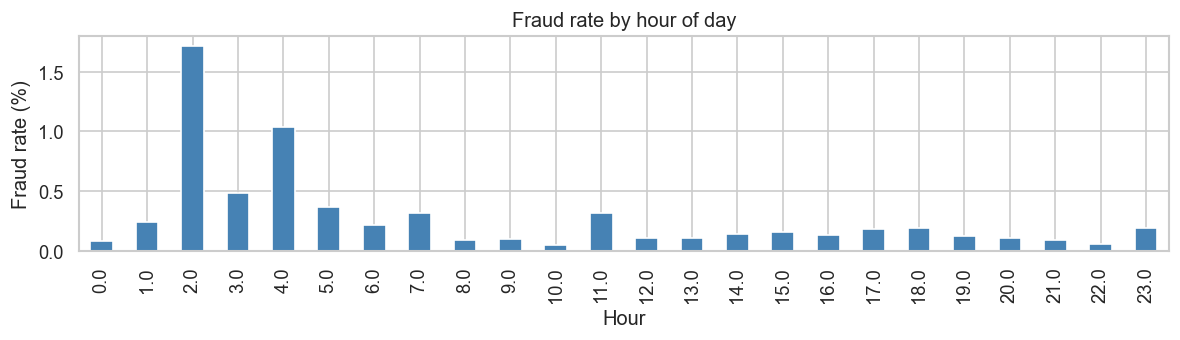

In [11]:
df['hour_of_day'] = (df['Time'] // 3600) % 24

hourly = df.groupby('hour_of_day')['Class'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 3))
hourly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Fraud rate by hour of day')
ax.set_xlabel('Hour')
ax.set_ylabel('Fraud rate (%)')
plt.tight_layout()
plt.savefig('../reports/figures/01_fraud_by_hour.png')
plt.show()

## 5. Feature correlations with Class

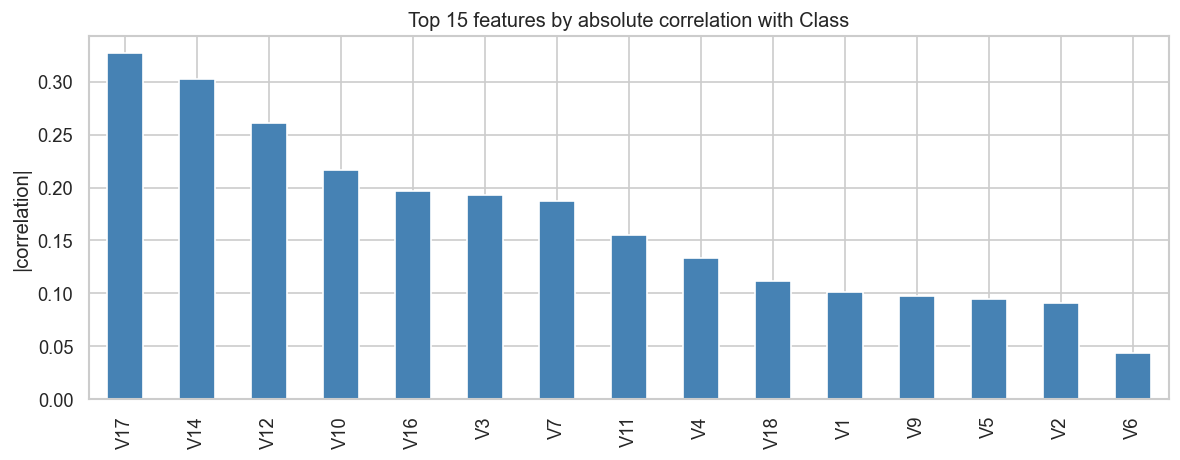

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [13]:
correlations = df.drop(columns=['Time', 'hour_of_day']).corr()['Class'].drop('Class')
correlations_sorted = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
correlations_sorted.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 features by absolute correlation with Class')
ax.set_ylabel('|correlation|')
plt.tight_layout()
plt.savefig('../reports/figures/01_feature_correlations.png')
plt.show()

print("Top 10 features correlated with fraud:")
print(correlations_sorted.head(10).to_string())

## 6. PCA feature separation — top 3 vs Class

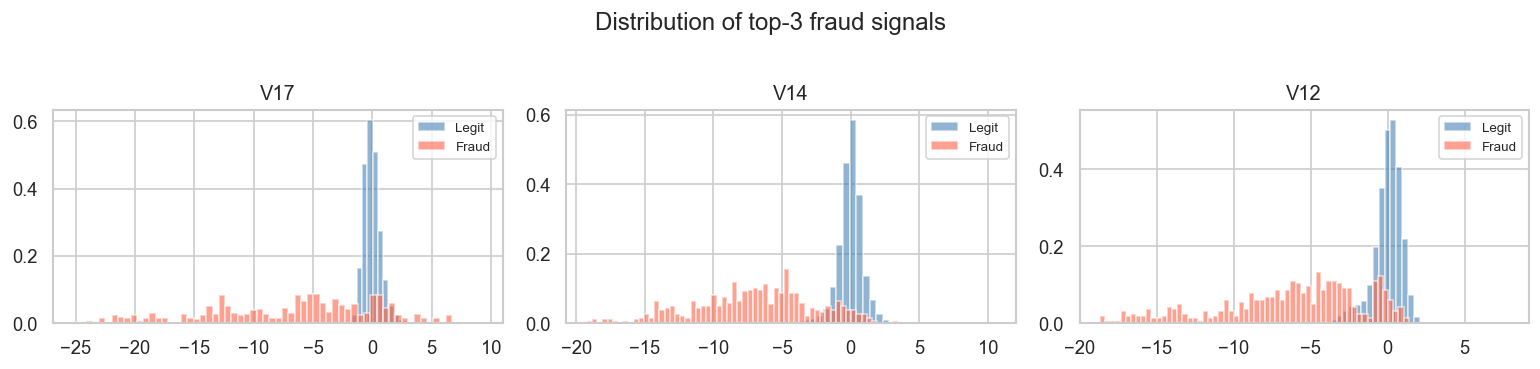

In [15]:
top3 = correlations_sorted.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, feat in zip(axes, top3):
    df[df['Class']==0][feat].hist(bins=60, ax=ax, alpha=0.6, label='Legit', color='steelblue', density=True)
    df[df['Class']==1][feat].hist(bins=60, ax=ax, alpha=0.6, label='Fraud', color='tomato', density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle('Distribution of top-3 fraud signals', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_top3_features.png')
plt.show()

## 7. EDA summary

In [17]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"\n1. CLASS IMBALANCE")
print(f"   Fraud rate: {fraud_rate:.4f}% — use class_weight or SMOTE.")
print(f"   Accuracy is a useless metric here; use PR-AUC.")
print(f"\n2. AMOUNT")
print(f"   Median: {df['Amount'].median():.2f}")
print(f"   Amount needs log scaling before modelling.")
print(f"\n3. TIME")
print(f"   Fraud rate varies by hour - time is a useful feature.")
print(f"   Convert raw seconds to hour-of-day.")
print(f"\n4. FEATURES")
top3 = correlations_sorted.head(3).index.tolist()
print(f"   Strongest fraud signals: {top3}")
print(f"   These PCA features show clear class separation.")
print(f"\n5. MISSING DATA")
print(f"   {df.isnull().sum().sum()} missing values - no imputation needed.")
print(f"\nNext step: notebook 02 - build a baseline model using these insights.")
print("=" * 55)

EDA SUMMARY

1. CLASS IMBALANCE
   Fraud rate: 0.1727% — use class_weight or SMOTE.
   Accuracy is a useless metric here; use PR-AUC.

2. AMOUNT
   Median: 22.00
   Amount needs log scaling before modelling.

3. TIME
   Fraud rate varies by hour - time is a useful feature.
   Convert raw seconds to hour-of-day.

4. FEATURES
   Strongest fraud signals: ['V17', 'V14', 'V12']
   These PCA features show clear class separation.

5. MISSING DATA
   0 missing values - no imputation needed.

Next step: notebook 02 - build a baseline model using these insights.
